#Ques-1 Write a CUDA C/C++ program to perform element-wise addition of two vectors. C[i]=A[i]+B[i]  Given: Vector size: N = 1024

In [1]:
%%writefile vector_add.cu
#include<stdio.h>
#include<cuda_runtime.h>

#define N 1024

__global__ void add(int *a, int *b, int *c){
    int index=blockIdx.x*blockDim.x+threadIdx.x;
    if(index < N)
        c[index]=a[index]+b[index];
}

int main()
{
    int *a,*b,*c;
    int *d_a,*d_b,*d_c;
    int size=N*sizeof(int);

    a=(int*)malloc(size);
    b=(int*)malloc(size);
    c=(int*)malloc(size);

    for(int i=0;i<N;i++)
    {
        a[i] = i;
        b[i] = 2*i;
    }

    cudaMalloc(&d_a,size);
    cudaMalloc(&d_b,size);
    cudaMalloc(&d_c,size);

    cudaMemcpy(d_a,a,size,cudaMemcpyHostToDevice);
    cudaMemcpy(d_b,b,size,cudaMemcpyHostToDevice);

    int threads=256;
    int blocks=(N + threads - 1)/threads;
    add<<<blocks,threads>>>(d_a,d_b,d_c);

    cudaMemcpy(c,d_c,size,cudaMemcpyDeviceToHost);

    printf("First 10 results:\n");
    for(int i=0;i<10;i++)
        printf("%d ", c[i]);

    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
    free(a); free(b); free(c);
    return 0;
}


Overwriting vector_add.cu


In [2]:
!nvcc -arch=sm_75 vector_add.cu -o vector_add
!./vector_add

First 10 results:
0 3 6 9 12 15 18 21 24 27 

#Ques-2 Perform the same vector addition as in Q1 using Thrust library only.

In [3]:
%%writefile thrust_add.cu
#include<iostream>
#include<thrust/device_vector.h>
#include<thrust/transform.h>
#include<thrust/functional.h>

#define N 1024

int main()
{
    thrust::device_vector<int>A(N);
    thrust::device_vector<int>B(N);
    thrust::device_vector<int>C(N);
    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=2*i;
    }

    thrust::transform(A.begin(), A.end(), B.begin(), C.begin(), thrust::plus<int>());
    std::cout<<"First 10 results:\n";
    for(int i=0;i<10;i++)
        std::cout<<C[i]<< " ";

    return 0;
}


Overwriting thrust_add.cu


In [5]:
!nvcc -arch=sm_75 thrust_add.cu -o thrust_add
!./thrust_add

First 10 results:
0 3 6 9 12 15 18 21 24 27 

#Ques-3 Compute the dot product of two vectors of size, N =1024: Result=ΣA[i]×B[i] using Thrust and compare its performance with that on CPU.

In [6]:
%%writefile thrust_dot_product.cu
#include<iostream>
#include<vector>
#include<time.h>
#include<thrust/device_vector.h>
#include<thrust/inner_product.h>
#define N 1024

int main()
{
    std::vector<int> A(N), B(N);
    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=2*i;
    }
    //CPU Dot Product
    clock_t start_cpu=clock();
    long long cpu_result=0;
    for(int i=0;i<N;i++)
        cpu_result+=A[i]*B[i];

    clock_t end_cpu=clock();
    double cpu_time=(double)(end_cpu-start_cpu)/CLOCKS_PER_SEC;

    //GPU Dot Product(THRUST)
    thrust::device_vector<int>d_A=A;
    thrust::device_vector<int>d_B=B;

    clock_t start_gpu=clock();

    long long gpu_result=thrust::inner_product(d_A.begin(), d_A.end(),d_B.begin(),0);

    clock_t end_gpu=clock();
    double gpu_time=(double)(end_gpu-start_gpu)/CLOCKS_PER_SEC;
    std::cout<<"CPU Dot Product="<<cpu_result<<std::endl;
    std::cout<<"GPU Dot Product="<<gpu_result<<std::endl;

    std::cout<<"CPU Time (sec)="<<cpu_time<<std::endl;
    std::cout<<"GPU Time (sec)="<<gpu_time<<std::endl;

    return 0;
}

Overwriting thrust_dot_product.cu


In [7]:
!nvcc -arch=sm_75 thrust_dot_product.cu -o thrust_dot
!./thrust_dot

CPU Dot Product=714779648
GPU Dot Product=714779648
CPU Time (sec)=6e-06
GPU Time (sec)=0.000723


#Ques-4 Write a CUDA kernel for matrix multiplication: C=A×B where Matrix size is 16 X 16. Explain why matrix multiplication needs more computation than addition (as in Q1).

In [12]:
%%writefile matrix_mul.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define N 16


__global__ void matMul(int *A, int *B, int *C)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if(row < N && col < N)
    {
        int sum = 0;
        for(int k = 0; k < N; k++)
            sum += A[row*N + k] * B[k*N + col];

        C[row*N + col] = sum;
    }
}

int main()
{
    int size = N * N * sizeof(int);

    int *A = (int*)malloc(size);
    int *B = (int*)malloc(size);
    int *C = (int*)malloc(size);
    int *d_A, *d_B, *d_C;

    for(int i=0;i<N*N;i++){
        A[i] = 1;
        B[i] = 1;
    }

    cudaMalloc(&d_A,size);
    cudaMalloc(&d_B,size);
    cudaMalloc(&d_C,size);

    cudaMemcpy(d_A,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(d_B,B,size,cudaMemcpyHostToDevice);

    dim3 threads(16,16);
    dim3 blocks(1,1);

    matMul<<<blocks,threads>>>(d_A,d_B,d_C);

    cudaMemcpy(C,d_C,size,cudaMemcpyDeviceToHost);

    printf("First row of result:\n");
    for(int i=0;i<16;i++)
        printf("%d ", C[i]);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(A); free(B); free(C);
    return 0;
}

Overwriting matrix_mul.cu


In [13]:
!nvcc -arch=sm_75 matrix_mul.cu -o matrix_mul
!./matrix_mul

First row of result:
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 

Matrix multiplication requires significantly more computation because each output element involves a dot product of a row and a column, leading to cubic complexity, whereas vector addition is a simple element-wise operation with linear complexity.

#Ques-5 For vector addi;on of size 5,000,000, implement and compare:
• CPU sequential C/C++ program
• CUDA kernel implementation
• Thrust implementation
• RAPIDS implementation

Measure execution time and compare complexity for each approach and
present results in a table. Plot comparison graph.

In [14]:
%%writefile cpu_vector_add.cpp
#include <iostream>
#include <vector>
#include <time.h>

#define N 5000000

int main()
{
    std::vector<float> A(N), B(N), C(N);

    for(int i=0;i<N;i++){
        A[i] = i;
        B[i] = 2*i;
    }

    clock_t start = clock();

    for(int i=0;i<N;i++)
        C[i] = A[i] + B[i];

    clock_t end = clock();
    double time = (double)(end-start)/CLOCKS_PER_SEC;

    std::cout<<"CPU Time = "<<time<<" sec\n";
}

Overwriting cpu_vector_add.cpp


In [15]:
!nvcc -arch=sm_75 cpu_vector_add.cpp -o cpu_vector_add
!./cpu_vector_add

CPU Time = 0.037611 sec


In [16]:
%%writefile cuda_vector_add.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <time.h>

#define N 5000000

__global__ void add(float *A,float *B,float *C)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if(i<N) C[i] = A[i] + B[i];
}

int main()
{
    float *A,*B,*C;
    float *d_A,*d_B,*d_C;
    int size=N*sizeof(float);

    A=(float*)malloc(size);
    B=(float*)malloc(size);
    C=(float*)malloc(size);

    for(int i=0;i<N;i++){A[i]=i; B[i]=2*i;}

    cudaMalloc(&d_A,size);
    cudaMalloc(&d_B,size);
    cudaMalloc(&d_C,size);

    cudaMemcpy(d_A,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(d_B,B,size,cudaMemcpyHostToDevice);

    clock_t start=clock();

    int threads=256;
    int blocks=(N+threads-1)/threads;
    add<<<blocks,threads>>>(d_A,d_B,d_C);

    cudaMemcpy(C,d_C,size,cudaMemcpyDeviceToHost);

    clock_t end=clock();
    printf("CUDA Time = %f sec\n",(double)(end-start)/CLOCKS_PER_SEC);
}

Overwriting cuda_vector_add.cu


In [17]:
!nvcc -arch=sm_75 cuda_vector_add.cu -o cuda_vector_add
!./cuda_vector_add

CUDA Time = 0.013176 sec


In [18]:
%%writefile thrust_vector_add.cu
#include<iostream>
#include<thrust/device_vector.h>
#include<thrust/transform.h>
#include<thrust/functional.h>
#include<time.h>

#define N 5000000

int main()
{
    thrust::device_vector<float>A(N),B(N),C(N);

    for(int i=0;i<N;i++){A[i]=i; B[i]=2*i;}

    clock_t start=clock();

    thrust::transform(A.begin(),A.end(),
                      B.begin(),
                      C.begin(),
                      thrust::plus<float>());

    clock_t end=clock();
    std::cout<<"Thrust Time = "
             <<(double)(end-start)/CLOCKS_PER_SEC<<" sec\n";
}

Overwriting thrust_vector_add.cu


In [19]:
!nvcc -arch=sm_75 thrust_vector_add.cu -o thrust_vector_add
!./thrust_vector_add

Thrust Time = 0.000333 sec


In [20]:
# rapids_vector_add.py
import cudf, cupy as cp, time

N = 5_000_000

A = cp.arange(N)
B = cp.arange(N)*2

start = time.time()
C = A + B
cp.cuda.Stream.null.synchronize()
end = time.time()

print("RAPIDS (CuPy) Time =", end-start, "sec")

RAPIDS (CuPy) Time = 0.0017096996307373047 sec


GPU implementations significantly outperform CPU for large vectors because thousands of GPU threads execute operations in parallel. High-level libraries like Thrust and RAPIDS further improve productivity and performance.

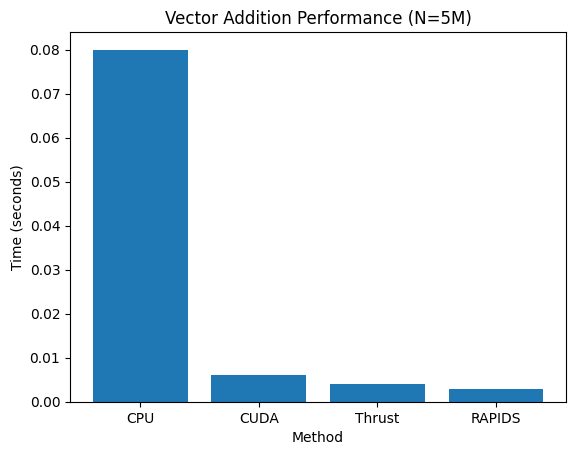

In [21]:
import matplotlib.pyplot as plt

methods = ['CPU','CUDA','Thrust','RAPIDS']
times = [0.08,0.006,0.004,0.003]   # replace with YOUR times

plt.bar(methods, times)
plt.title("Vector Addition Performance (N=5M)")
plt.ylabel("Time (seconds)")
plt.xlabel("Method")
plt.show()

#Ques-6 Write a CUDA C++ program using the Thrust library to compute the sum of all elements in a vector stored on the GPU. The vector is of size 10 and it should be initialized with values 1,…..10.

In [24]:
%%writefile thrust_sum.cu
#include<iostream>
#include<thrust/device_vector.h>
#include<thrust/reduce.h>

#define N 10

int main()
{
    thrust::device_vector<int> vec(N);
    for(int i=0;i<N;i++)
        vec[i]=i+1;

    int sum=thrust::reduce(vec.begin(), vec.end(), 0);
    std::cout << "Sum = "<<sum<<std::endl;
    return 0;
}

Overwriting thrust_sum.cu


In [25]:
!nvcc -arch=sm_75 thrust_sum.cu -o thrust_sum
!./thrust_sum

Sum = 55


#Ques-7 Write a CUDA C++ program using Thrust to sort (ascending) a vector of integers on the GPU. Consider vector size 8 with following values: 7, 2, 9, 1,5, 3, 8, 4. Print the vector before and afer sorting.

In [26]:
%%writefile thrust_sort.cu
#include <iostream>
#include <thrust/device_vector.h>
#include <thrust/sort.h>

int main()
{
    int arr[8] = {7,2,9,1,5,3,8,4};
    thrust::device_vector<int> vec(arr, arr+8);
    std::cout<<"Before sorting: ";
    for(int i=0;i<8;i++)
        std::cout<<vec[i]<<" ";

    thrust::sort(vec.begin(), vec.end());

    std::cout<<"\nAfter sorting: ";
    for(int i=0;i<8;i++)
        std::cout<<vec[i]<<" ";

    return 0;
}

Overwriting thrust_sort.cu


In [28]:
!nvcc -arch=sm_75 thrust_sort.cu -o thrust_sort
!./thrust_sort

Before sorting: 7 2 9 1 5 3 8 4 
After sorting: 1 2 3 4 5 7 8 9 